# Multi-panel figures, done properly

A multi-panel figure is where most papers lose their typography. This notebook covers the mechanics —
`subplots`, `mosaic`, `gridspec`, panel labels — and then the habits that separate a figure that
merely fits from one that reads as deliberate.

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.5.1 | themes: ('nature', 'aps', 'elsevier')


## First: fix the height

Height defaults to the inverse golden ratio of the **width**. That is right for one panel and far too
short for two rows — the panels get squashed and the labels collide. Always pass `ratio=` or
`height_mm=` deliberately for a grid.

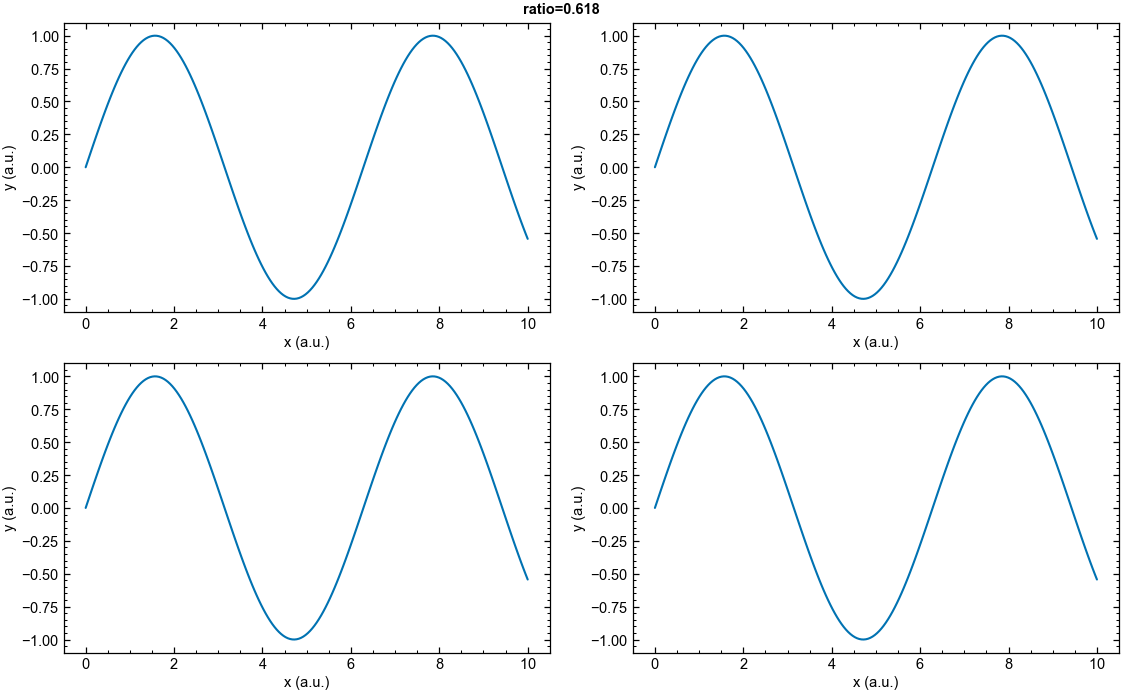

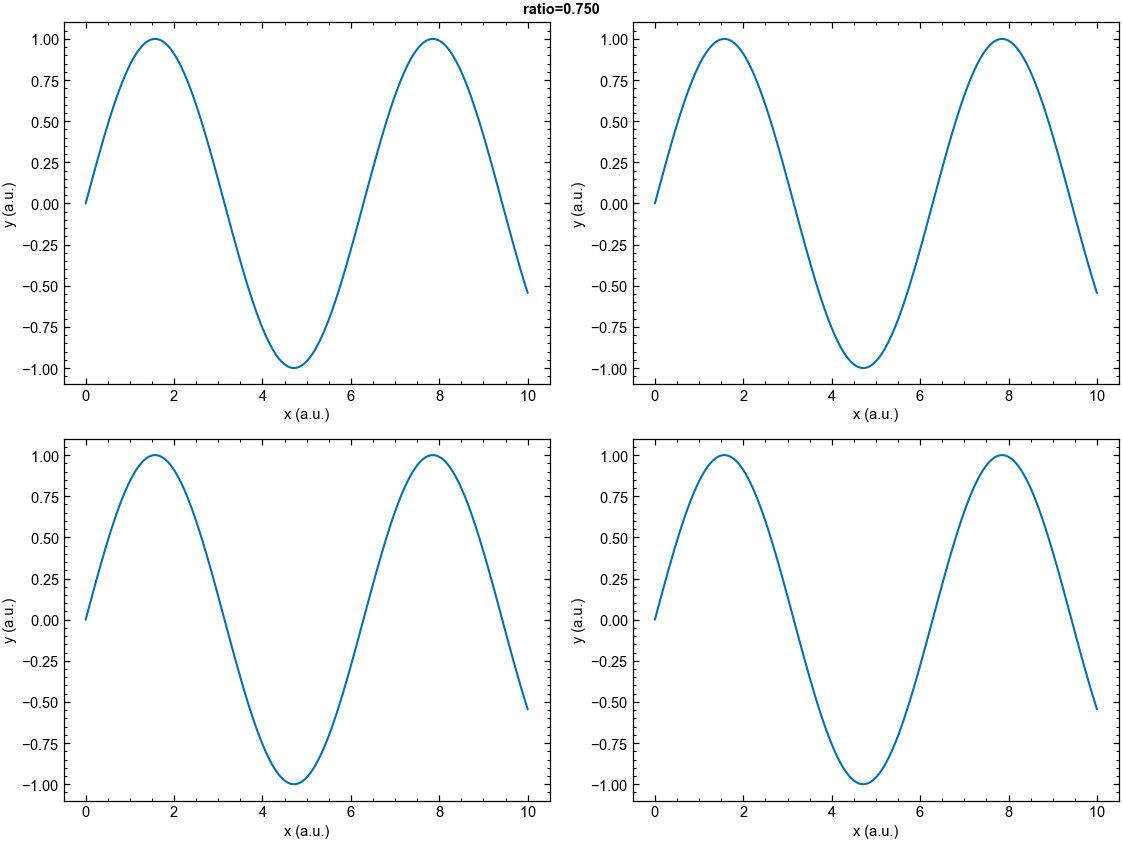

In [2]:
preview("elsevier")
x = np.linspace(0, 10, 200)

for ratio in (jf.GOLDEN, 0.75):
    fig, axs = jf.subplots("elsevier", 2, 2, width="double", ratio=ratio)
    for ax in axs.flat:
        ax.plot(x, np.sin(x))
        ax.set_xlabel("x (a.u.)")
        ax.set_ylabel("y (a.u.)")
    fig.suptitle(f"ratio={ratio:.3f}", fontsize=7)
    plt.show()

## Panel labels

Nature wants bare lowercase letters; APS and Elsevier want parentheses. `jf.panel_labels()` uses the
convention of the active theme and letters the panels in reading order.

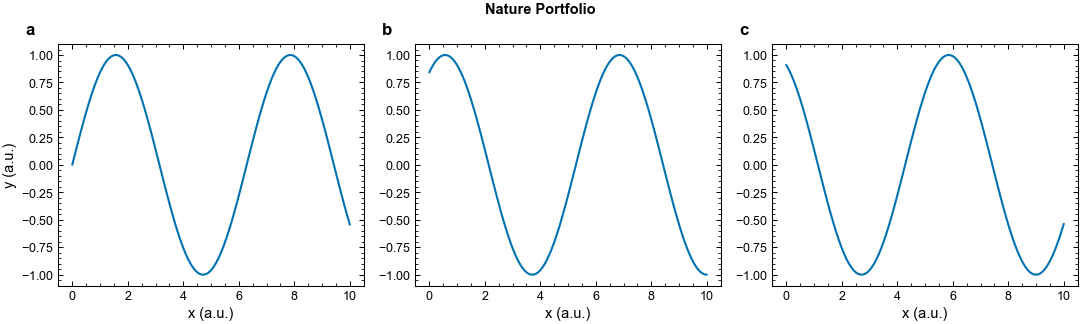

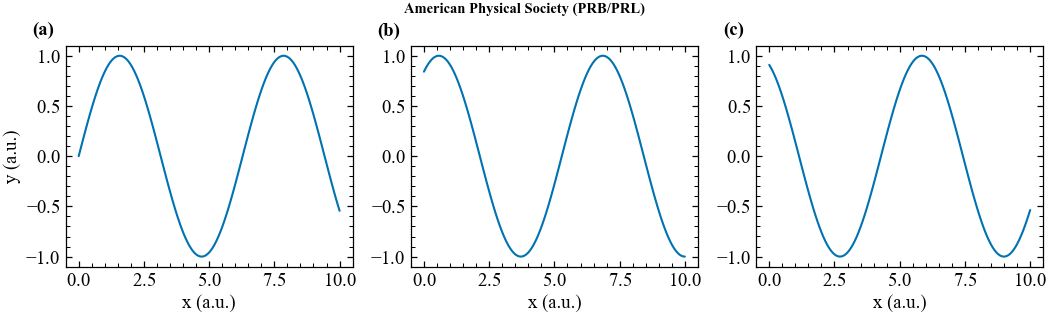

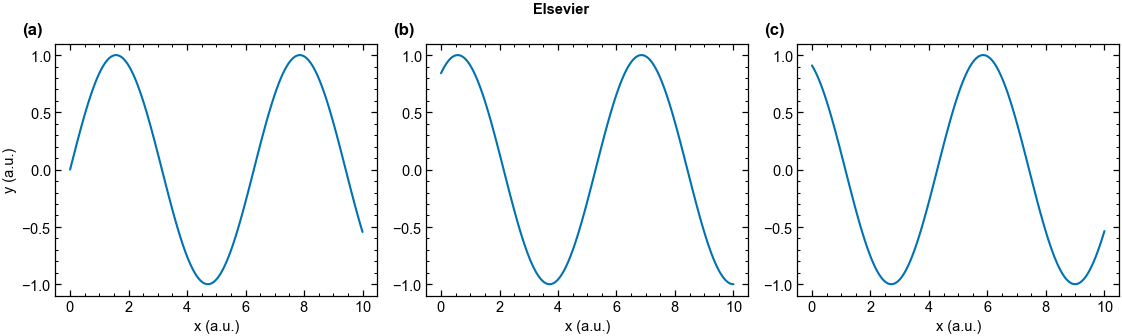

In [3]:
for journal in jf.JOURNALS:
    preview(journal)
    fig, axs = jf.subplots(journal, 1, 3, width="double", ratio=0.3)
    for i, ax in enumerate(axs):
        ax.plot(x, np.sin(x + i))
        ax.set_xlabel("x (a.u.)")
    axs[0].set_ylabel("y (a.u.)")
    jf.panel_labels(axs)
    fig.suptitle(jf.get_spec(journal).name, fontsize=7)
    plt.show()

## Do not repeat yourself

Two habits do more for a multi-panel figure than anything else:

1. **Share the axes** when panels use the same scale, then drop the redundant tick labels. Repeated
   numbers down a column are noise, and removing them buys space for the data.
2. **Label once.** `fig.supxlabel` / `fig.supylabel` put a single shared label where four would have
   gone.

[Text(-16.0, 3.0, 'a'),
 Text(-16.0, 3.0, 'b'),
 Text(-16.0, 3.0, 'c'),
 Text(-16.0, 3.0, 'd')]

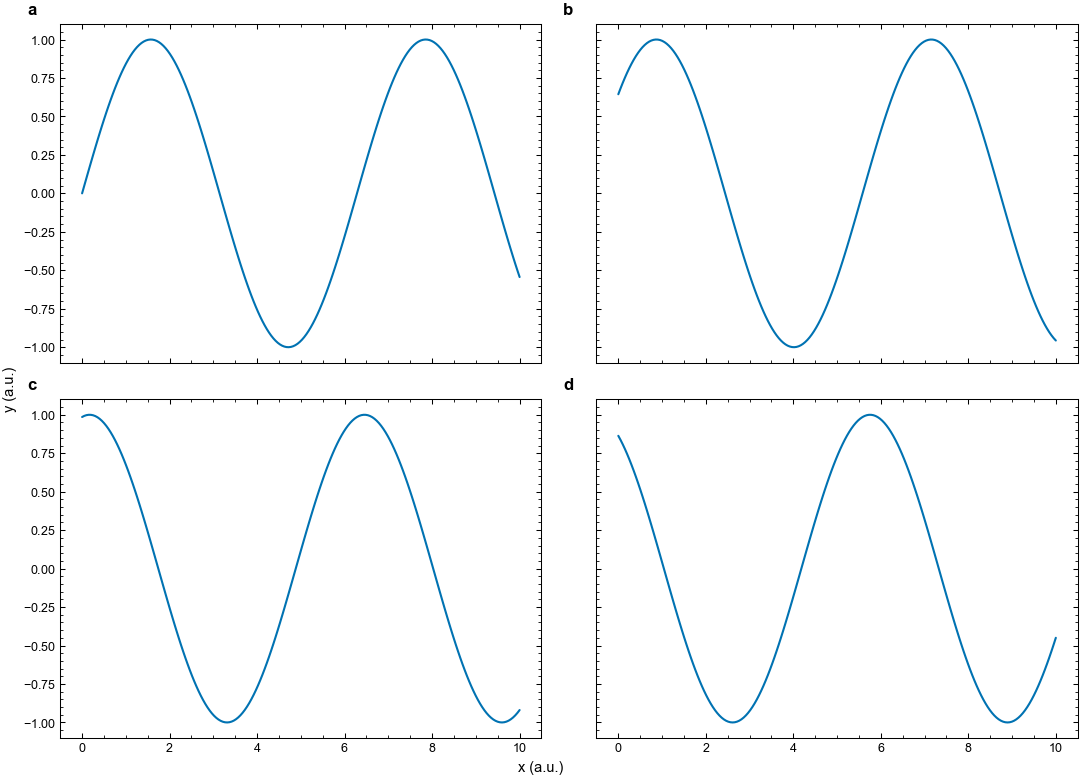

In [4]:
preview("nature")
fig, axs = jf.subplots("nature", 2, 2, width="double", ratio=0.72, sharex=True, sharey=True)
for i, ax in enumerate(axs.flat):
    ax.plot(x, np.sin(x + i * 0.7))
fig.supxlabel("x (a.u.)", fontsize=7)
fig.supylabel("y (a.u.)", fontsize=7)
jf.panel_labels(axs)

## Keep the limits identical

If panels are meant to be compared, they must share limits — otherwise the reader compares shapes on
different scales and draws the wrong conclusion. `sharex`/`sharey` do this for you; set them by hand
when the panels are not shared.

Text(0, 0.5, 'shared limits')

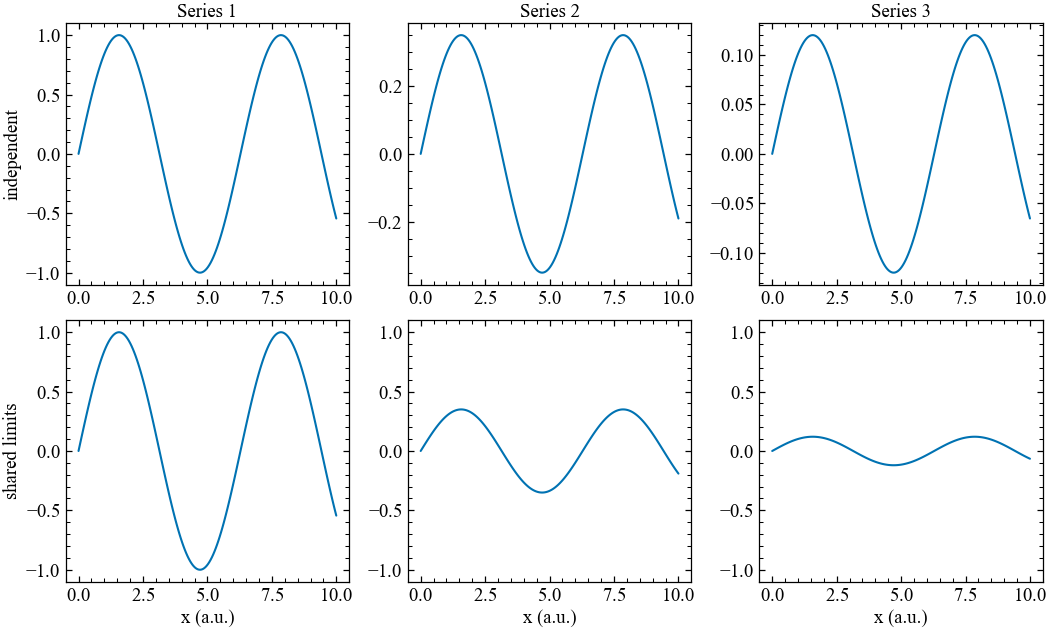

In [5]:
preview("aps")
series = [np.sin(x) * amp for amp in (1.0, 0.35, 0.12)]

fig, axs = jf.subplots("aps", 2, 3, width="double", ratio=0.6)
for i, data in enumerate(series):
    axs[0, i].plot(x, data)
    axs[0, i].set_title(f"Series {i + 1}")
    axs[1, i].plot(x, data)
    axs[1, i].set_ylim(-1.1, 1.1)
    axs[1, i].set_xlabel("x (a.u.)")
axs[0, 0].set_ylabel("independent")
axs[1, 0].set_ylabel("shared limits")

## One legend, not four

A legend repeated in every panel wastes the space the panels needed. Put it once, outside the axes.

[Text(-16.0, 3.0, '(a)'), Text(-16.0, 3.0, '(b)'), Text(-16.0, 3.0, '(c)')]

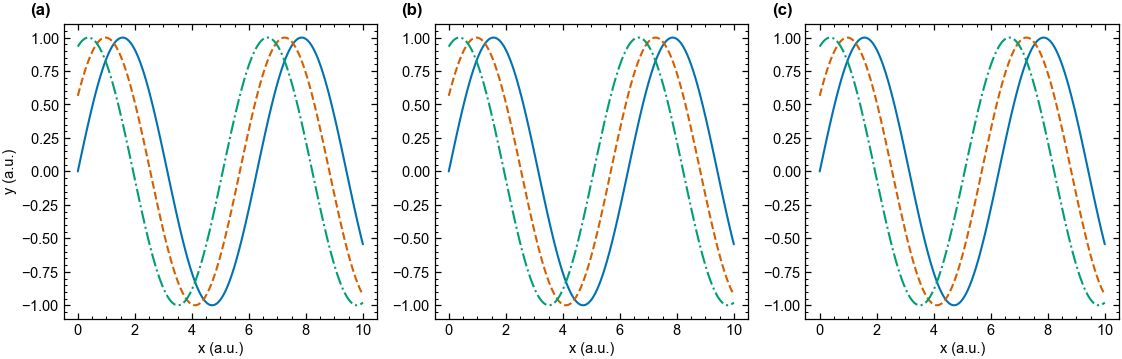

In [6]:
preview("elsevier")
fig, axs = jf.subplots("elsevier", 1, 3, width="double", ratio=0.32)
for ax in axs:
    for i in range(3):
        ax.plot(x, np.sin(x + i * 0.6), label=f"Series {i + 1}")
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncols=3, bbox_to_anchor=(0.5, 1.06), frameon=False)
jf.panel_labels(axs)

## Panels of different sizes: `jf.mosaic`

Sketch the layout as text — one character per grid cell, repeated where a panel should span, `.` where
it should stay empty. `width_ratios` and `height_ratios` then set how large the columns and rows are
relative to each other, so panels need not be multiples of one cell.

panels in reading order: ['A', 'B', 'C', 'D']


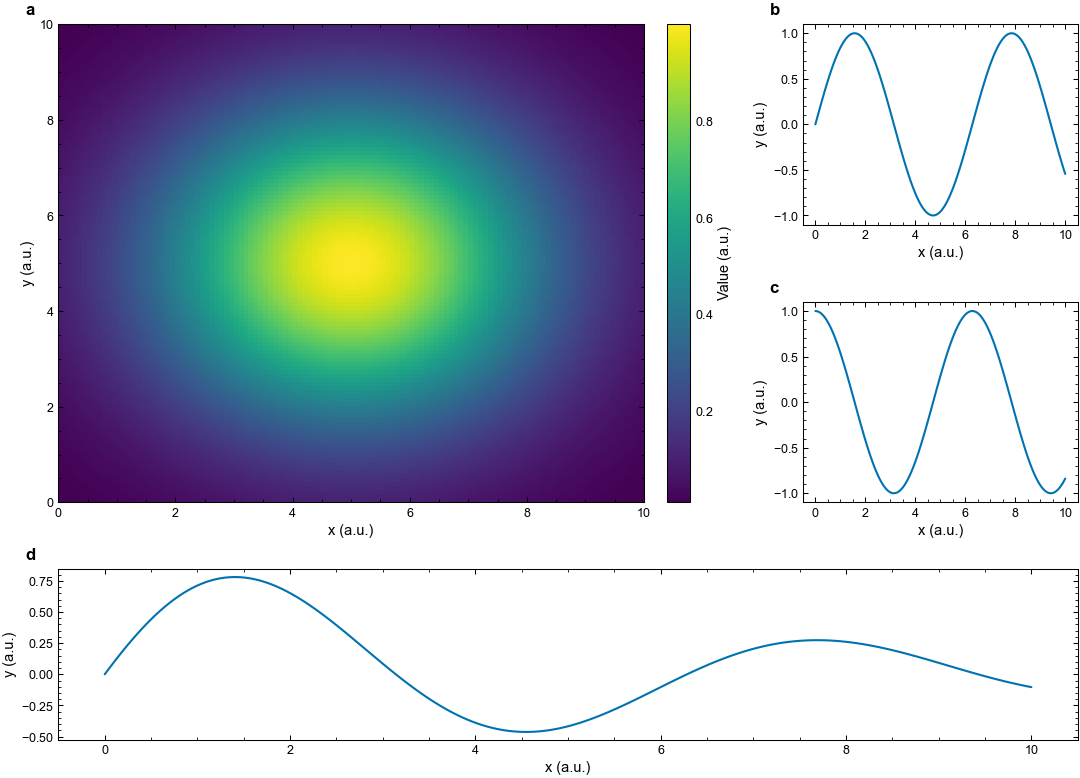

In [7]:
preview("nature")
fig, panels = jf.mosaic(
    "nature",
    "AAB\n"   # a large panel spanning two rows and two columns,
    "AAC\n"   # two small panels stacked beside it,
    "DDD",    # and a wide strip underneath
    width="double",
    ratio=0.72,
    width_ratios=[1, 1, 1.15],
    height_ratios=[1, 1, 0.85],
)

grid = np.linspace(-3, 3, 120)
field = np.exp(-((grid[:, None] ** 2 + grid[None, :] ** 2) / 4))
mesh = panels["A"].imshow(field, extent=(0, 10, 0, 10), origin="lower", aspect="auto")
fig.colorbar(mesh, ax=panels["A"], label="Value (a.u.)", fraction=0.05, pad=-0.05)
panels["B"].plot(x, np.sin(x))
panels["C"].plot(x, np.cos(x))
panels["D"].plot(x, np.sin(x) * np.exp(-x / 6))

for name in "ABCD":
    panels[name].set_xlabel("x (a.u.)")
    panels[name].set_ylabel("y (a.u.)")
jf.panel_labels(panels)
print("panels in reading order:", list(panels))

`panels` maps each name in the sketch to its axes, in the order the names first appear reading left to
right and top to bottom — which is the order `jf.panel_labels` letters them. Pass
`labels=list(panels)` if you would rather label them with the sketch's own names.

a '.' cell stays empty; axes drawn: 2


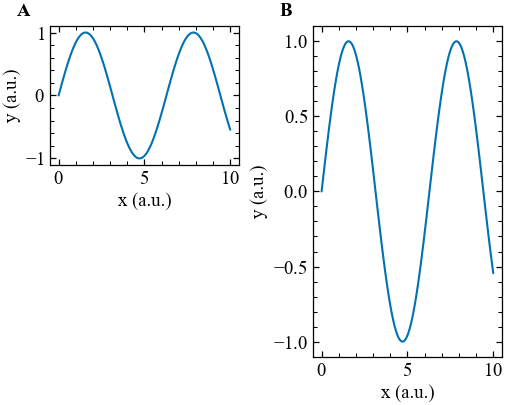

In [8]:
preview("aps")
fig, panels = jf.mosaic("aps", "AB\n.B", width="single", ratio=0.8)
for name, ax in panels.items():
    ax.plot(x, np.sin(x))
    ax.set_xlabel("x (a.u.)")
    ax.set_ylabel("y (a.u.)")
jf.panel_labels(panels, labels=list(panels))
print("a '.' cell stays empty; axes drawn:", len(fig.get_axes()))

## `jf.gridspec` when slices are clearer than a sketch

Some layouts are easier to describe as slices. `jf.gridspec` hands back the figure and an empty grid,
sized and pinned exactly like `jf.subplots`.

[Text(-16.0, 3.0, '(a)'), Text(-16.0, 3.0, '(b)'), Text(-16.0, 3.0, '(c)')]

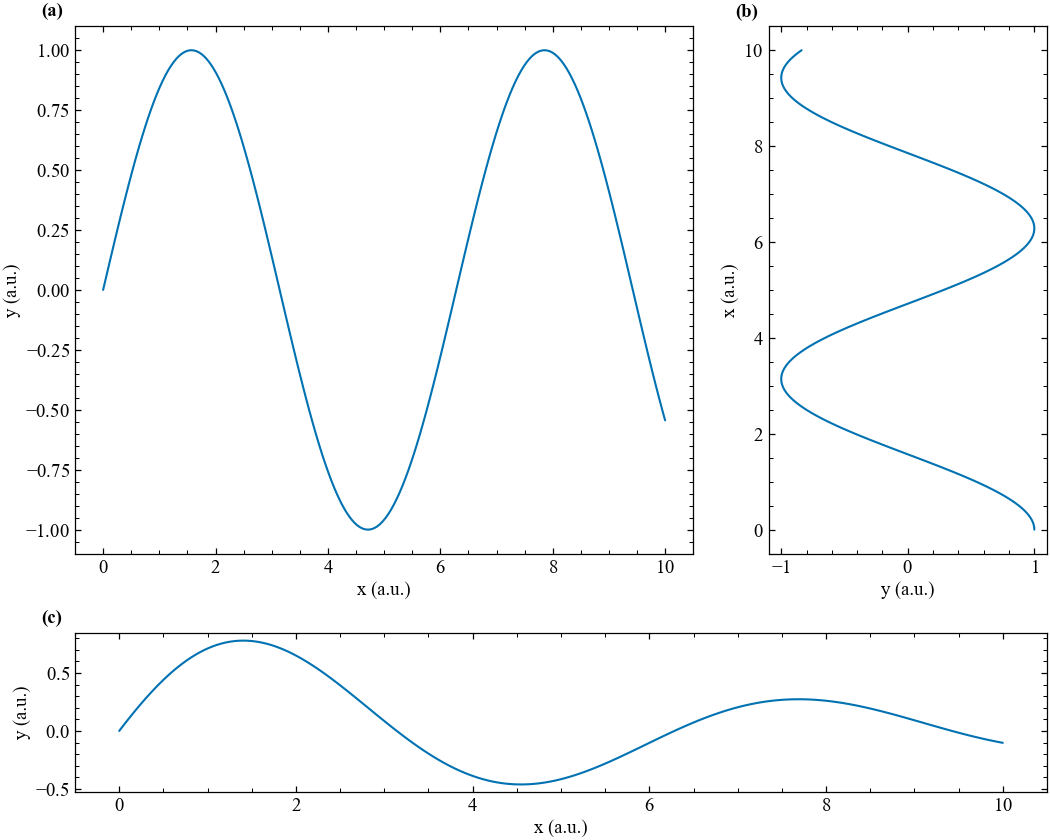

In [9]:
preview("aps")
fig, gs = jf.gridspec("aps", 3, 3, width="double", ratio=0.8, height_ratios=[1, 1, 0.6])

main = fig.add_subplot(gs[:2, :2])
side = fig.add_subplot(gs[:2, 2])
strip = fig.add_subplot(gs[2, :])

main.plot(x, np.sin(x))
side.plot(np.cos(x), x)
strip.plot(x, np.sin(x) * np.exp(-x / 6))
for ax, xlabel, ylabel in [(main, "x (a.u.)", "y (a.u.)"), (side, "y (a.u.)", "x (a.u.)"),
                           (strip, "x (a.u.)", "y (a.u.)")]:
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
jf.panel_labels([main, side, strip])

## Unequal columns without either

For a plain grid whose columns merely differ in width, `jf.subplots` forwards `width_ratios` and
`height_ratios` straight to matplotlib.

[Text(-16.0, 3.0, '(a)'), Text(-16.0, 3.0, '(b)')]

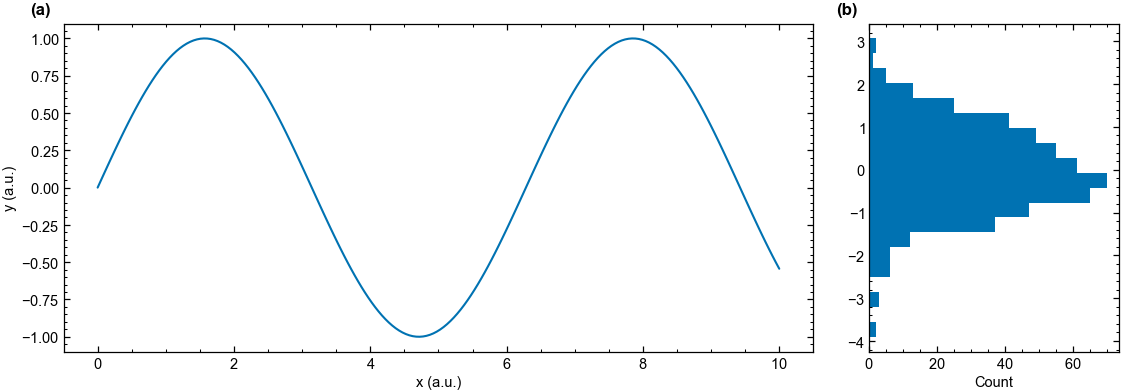

In [10]:
preview("elsevier")
fig, axs = jf.subplots("elsevier", 1, 2, width="double", ratio=0.35, width_ratios=[3, 1])
axs[0].plot(x, np.sin(x))
axs[1].hist(rng.normal(size=500), bins=20, orientation="horizontal")
axs[0].set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")
axs[1].set_xlabel("Count")
jf.panel_labels(axs)

## Check the whole figure before saving

`jf.check()` walks every artist in the figure, so it covers all panels at once. `jf.save()` runs it
for you unless you pass `validate=False`.

In [11]:
jf.use("nature")
fig, axs = jf.subplots("nature", 1, 2, width="double", ratio=0.4)
for ax in axs:
    ax.plot(x, np.sin(x))
    ax.set_xlabel("x (a.u.)")
axs[0].set_ylabel("y (a.u.)")
axs[1].set_xlabel("$x_{1}$ (a.u.)", fontsize=4)
jf.panel_labels(axs)

for violation in jf.check(fig, warn=False):
    print(violation)
plt.close(fig)

[text] '$x_{1}$ (a.u.)' is 4.0 pt, below the 5 pt minimum
[subscript] '$x_{1}$ (a.u.)' renders sub/superscripts at 2.80 pt (4.0 pt x 0.7), below the 5 pt floor


## Checklist

- Set `ratio=` or `height_mm=` — the golden-ratio default is a one-panel default.
- Share axes and delete the tick labels that repeat; label once with `supxlabel`/`supylabel`.
- Give panels that are meant to be compared identical limits.
- One legend for the figure, placed outside the panels.
- Label panels with `jf.panel_labels()` so the convention matches the journal.
- On a spanning panel, pass `fraction=0.05, pad=0.02` to `fig.colorbar`.
- Run `jf.check()` on the finished figure, not on each panel as you build it.